# 🦅 LegalEagle — NER on CUAD Contract Dataset

This notebook:
1. **Explores** the CUAD dataset — entity types like parties, dates, termination clauses, etc.
2. **Fine-tunes BERT** for token-classification (NER) using HuggingFace Trainer API
3. **Evaluates** the model — F1 per entity class + confusion matrix
4. **Saves** the fine-tuned model with `model.save_pretrained()`

## 0 — Install & Import

In [ ]:
import os, re, json, random, warnings
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_from_disk, Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification
)
from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score as seq_f1
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## 1 — Load & Verify CUAD Dataset

In [ ]:
raw = load_from_disk("../data/cuad")
print(raw)
row = raw["train"][0]
contracts = row["data"]
print(f"\nContracts loaded: {len(contracts)}")
print(f"Sample title: {contracts[0]['title']}")

## 2 — Explore CUAD: Entity / Clause Types

CUAD is a QA dataset. Each question maps to a **clause type** (entity category). We extract the clause name from the question text.

In [ ]:
# Extract clause types
clause_types = set()
for c in contracts:
    for p in c["paragraphs"]:
        for qa in p["qas"]:
            m = re.search(r'"([^"]+)"', qa["question"])
            if m:
                clause_types.add(m.group(1))

clause_types = sorted(clause_types)
print(f"Total clause types: {len(clause_types)}\n")
for i, ct in enumerate(clause_types, 1):
    print(f"  {i:2d}. {ct}")

### 2.1 — Distribution of Answered vs Unanswered Clauses

In [ ]:
ans_counts = Counter()
noans_counts = Counter()
for c in contracts:
    for p in c["paragraphs"]:
        for qa in p["qas"]:
            m = re.search(r'"([^"]+)"', qa["question"])
            if not m:
                continue
            ct = m.group(1)
            if qa["is_impossible"]:
                noans_counts[ct] += 1
            else:
                ans_counts[ct] += 1

fig, ax = plt.subplots(figsize=(14, 8))
cts = sorted(ans_counts.keys())
y = np.arange(len(cts))
ax.barh(y, [ans_counts[c] for c in cts], label="Has answer", color="#4CAF50")
ax.barh(y, [-noans_counts.get(c, 0) for c in cts], label="No answer", color="#F44336")
ax.set_yticks(y)
ax.set_yticklabels(cts, fontsize=8)
ax.set_xlabel("Count")
ax.set_title("CUAD Clause Distribution (answered vs unanswered)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 — Sample Extracted Clauses

In [ ]:
# Show sample answers for key clause types
key_types = ["Parties", "Agreement Date", "Termination For Convenience",
             "Governing Law", "Non-Compete", "Liquidated Damages"]

for ct in key_types:
    print(f"\n{'='*60}")
    print(f"  CLAUSE: {ct}")
    print(f"{'='*60}")
    found = 0
    for c in contracts:
        if found >= 2:
            break
        for p in c["paragraphs"]:
            for qa in p["qas"]:
                if found >= 2:
                    break
                m = re.search(r'"([^"]+)"', qa["question"])
                if m and m.group(1) == ct and not qa["is_impossible"] and qa["answers"]:
                    txt = qa["answers"][0]["text"][:200]
                    print(f"  [{c['title'][:50]}] → {txt}")
                    found += 1

## 3 — Convert CUAD → NER (BIO tagging)

We select a focused set of entity types for NER, convert QA spans to BIO token labels.

In [ ]:
# We pick 8 representative clause types to keep NER tractable
SELECTED_TYPES = [
    "Parties",
    "Agreement Date",
    "Effective Date",
    "Governing Law",
    "Termination For Convenience",
    "Non-Compete",
    "Liquidated Damages",
    "Renewal Term",
]

# Build label list: O + B-/I- for each type
label_list = ["O"]
for t in SELECTED_TYPES:
    tag = t.replace(" ", "_")
    label_list.append(f"B-{tag}")
    label_list.append(f"I-{tag}")

label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for i, l in enumerate(label_list)}

print(f"Labels ({len(label_list)}):")
for l in label_list:
    print(f"  {label2id[l]:2d}: {l}")

In [ ]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 256  # keep short for speed

def build_ner_samples(contracts, max_contracts=100):
    """Convert CUAD QA format → NER token-classification samples."""
    samples = []
    for ci, c in enumerate(contracts[:max_contracts]):
        for p in c["paragraphs"]:
            context = p["context"]
            # Collect all answer spans for selected types
            spans = []  # (start, end, type_tag)
            for qa in p["qas"]:
                m = re.search(r'"([^"]+)"', qa["question"])
                if not m or m.group(1) not in SELECTED_TYPES:
                    continue
                if qa["is_impossible"]:
                    continue
                tag = m.group(1).replace(" ", "_")
                for ans in qa["answers"]:
                    s = ans["answer_start"]
                    e = s + len(ans["text"])
                    spans.append((s, e, tag))

            # Tokenize and align labels
            # We chunk context into MAX_LEN-sized pieces
            for chunk_start in range(0, len(context), MAX_LEN * 4):
                chunk = context[chunk_start:chunk_start + MAX_LEN * 4]
                enc = tokenizer(
                    chunk, truncation=True, max_length=MAX_LEN,
                    return_offsets_mapping=True, padding="max_length"
                )
                offsets = enc.pop("offset_mapping")
                labels = [label2id["O"]] * len(offsets)

                for s, e, tag in spans:
                    # Adjust span to chunk
                    cs = s - chunk_start
                    ce = e - chunk_start
                    if cs < 0 or ce > len(chunk):
                        continue
                    first = True
                    for idx, (ts, te) in enumerate(offsets):
                        if ts == 0 and te == 0:
                            continue
                        if ts >= cs and te <= ce:
                            if first:
                                labels[idx] = label2id[f"B-{tag}"]
                                first = False
                            else:
                                labels[idx] = label2id[f"I-{tag}"]

                # Only keep if there is at least one non-O label
                if any(l != label2id["O"] for l in labels):
                    enc["labels"] = labels
                    samples.append(enc)

        if (ci + 1) % 20 == 0:
            print(f"  Processed {ci+1}/{min(len(contracts), max_contracts)} contracts, {len(samples)} samples so far")

    return samples

print("Converting CUAD to NER format...")
all_samples = build_ner_samples(contracts, max_contracts=150)
print(f"\nTotal NER samples: {len(all_samples)}")

# Label distribution
lbl_counter = Counter()
for s in all_samples:
    for l in s["labels"]:
        lbl_counter[id2label[l]] += 1

print("\nLabel distribution:")
for l in label_list:
    print(f"  {l:35s}: {lbl_counter.get(l, 0):6d}")

### 3.1 — Create Train / Validation Split

In [ ]:
random.seed(42)
random.shuffle(all_samples)

split = int(0.8 * len(all_samples))
train_data = all_samples[:split]
val_data = all_samples[split:]

def to_hf_dataset(samples):
    d = {
        "input_ids": [s["input_ids"] for s in samples],
        "attention_mask": [s["attention_mask"] for s in samples],
        "labels": [s["labels"] for s in samples],
    }
    return Dataset.from_dict(d)

train_ds = to_hf_dataset(train_data)
val_ds = to_hf_dataset(val_data)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

## 4 — Fine-tune BERT for NER using HuggingFace Trainer API

In [ ]:
model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)
model.to(device)
print(f"Model loaded: {MODEL_NAME} → {len(label_list)} labels")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
data_collator = DataCollatorForTokenClassification(tokenizer)

training_args = TrainingArguments(
    output_dir="../models/bert-ner-cuad",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to="none",
)

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    preds = np.argmax(preds, axis=-1)
    true_labels, true_preds = [], []
    for pred_seq, label_seq in zip(preds, labels):
        t, p = [], []
        for pr, lb in zip(pred_seq, label_seq):
            if lb == -100:
                continue
            t.append(id2label[lb])
            p.append(id2label[pr])
        true_labels.append(t)
        true_preds.append(p)
    f1 = seq_f1(true_labels, true_preds, average="weighted", zero_division=0)
    return {"f1": f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting training...")
trainer.train()
print("Training complete!")

## 5 — Evaluate NER Model: F1 per Entity Class + Confusion Matrix

In [ ]:
# Get predictions
preds_output = trainer.predict(val_ds)
preds = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids

# Build seqeval-format lists
true_labels, pred_labels = [], []
all_true_flat, all_pred_flat = [], []

for pred_seq, label_seq in zip(preds, labels):
    t_seq, p_seq = [], []
    for pr, lb in zip(pred_seq, label_seq):
        if lb == -100:
            continue
        t_seq.append(id2label[lb])
        p_seq.append(id2label[pr])
        all_true_flat.append(id2label[lb])
        all_pred_flat.append(id2label[pr])
    true_labels.append(t_seq)
    pred_labels.append(p_seq)

print("=" * 70)
print("  CLASSIFICATION REPORT (seqeval)")
print("=" * 70)
print(seq_report(true_labels, pred_labels, zero_division=0))

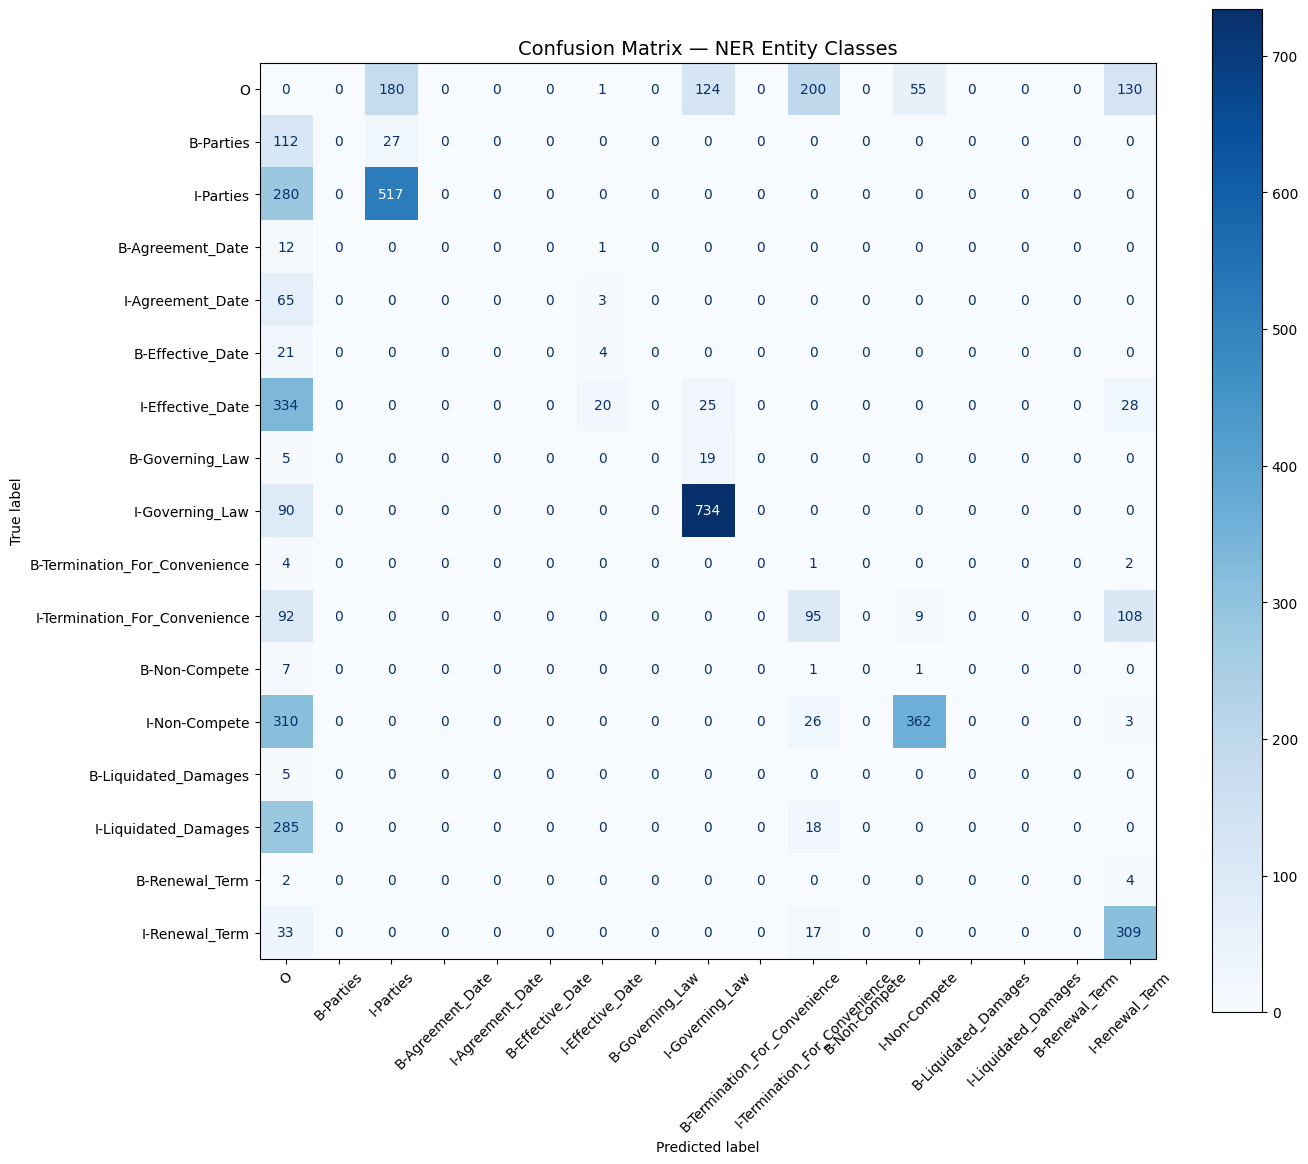

In [18]:
# Confusion matrix for non-O labels
entity_labels = [l for l in label_list if l != "O"]

# Filter to only entity tokens for clearer matrix
mask = [(t != "O" or p != "O") for t, p in zip(all_true_flat, all_pred_flat)]
filt_true = [t for t, m in zip(all_true_flat, mask) if m]
filt_pred = [p for p, m in zip(all_pred_flat, mask) if m]

# Include O in the matrix since some entities get predicted as O
present_labels = sorted(set(filt_true + filt_pred), key=lambda x: label_list.index(x) if x in label_list else 999)

cm = confusion_matrix(filt_true, filt_pred, labels=present_labels)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=present_labels)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
ax.set_title("Confusion Matrix — NER Entity Classes", fontsize=14)
plt.tight_layout()
plt.show()

### 5.1 — F1 Score per Entity Type (Bar Chart)

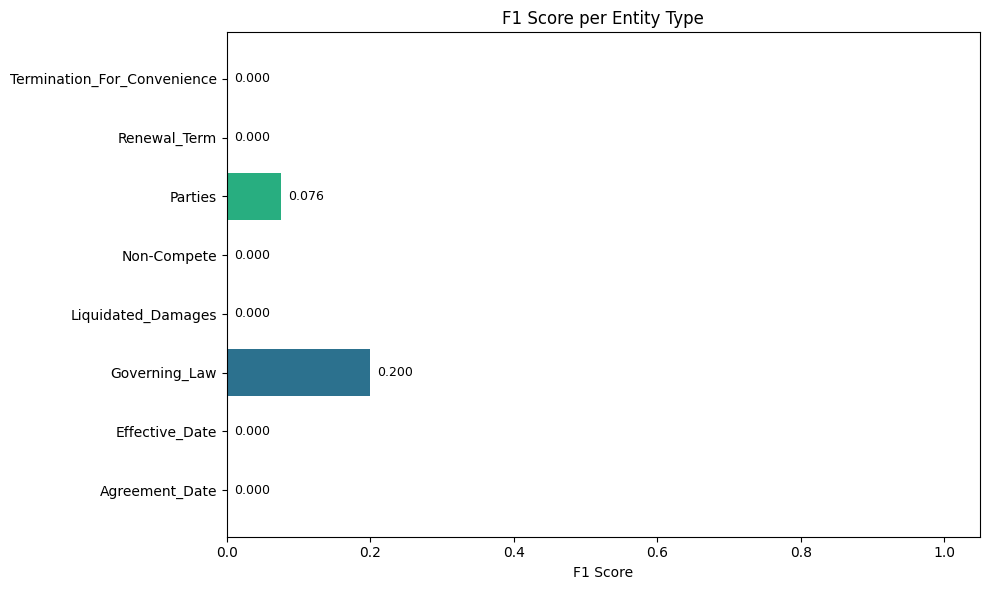

In [17]:
report_dict = seq_report(true_labels, pred_labels, zero_division=0, output_dict=True)
entity_names = [k for k in report_dict.keys() if k not in ("micro avg", "macro avg", "weighted avg")]
f1_scores = [report_dict[k]["f1-score"] for k in entity_names]

if entity_names:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(entity_names)))
    bars = ax.barh(entity_names, f1_scores, color=colors)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("F1 Score")
    ax.set_title("F1 Score per Entity Type")
    for bar, score in zip(bars, f1_scores):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{score:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("No entity-level scores found (model may need more training)")

## 6 — Save Fine-tuned Model Locally

In [16]:
save_path = "../models/bert-ner-cuad-final"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to: {os.path.abspath(save_path)}")
print(f"Contents: {os.listdir(save_path)}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: c:\Users\Saahil Saitwal\OneDrive\Desktop\LegalEagle\models\bert-ner-cuad-final
Contents: ['config.json', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json']


## 7 — Quick Inference Demo

In [15]:
def predict_entities(text, model, tokenizer):
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
    preds = torch.argmax(logits, dim=-1)[0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].cpu())

    entities = []
    current_entity, current_type = [], None
    for tok, pred_id in zip(tokens, preds):
        label = id2label[pred_id]
        if label.startswith("B-"):
            if current_entity:
                entities.append((current_type, tokenizer.convert_tokens_to_string(current_entity)))
            current_entity = [tok]
            current_type = label[2:]
        elif label.startswith("I-") and current_type == label[2:]:
            current_entity.append(tok)
        else:
            if current_entity:
                entities.append((current_type, tokenizer.convert_tokens_to_string(current_entity)))
                current_entity, current_type = [], None
    if current_entity:
        entities.append((current_type, tokenizer.convert_tokens_to_string(current_entity)))
    return entities

# Test with a sample from the dataset
sample_contract = contracts[0]
sample_text = sample_contract["paragraphs"][0]["context"][:500]
print(f"Contract: {sample_contract['title']}")
print(f"Text: {sample_text[:200]}...\n")

entities = predict_entities(sample_text, model, tokenizer)
if entities:
    print("Detected entities:")
    for etype, etext in entities:
        print(f"  [{etype}] → {etext}")
else:
    print("No entities detected in this snippet (try a different passage)")

Contract: LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT
Text: EXHIBIT 10.6

                              DISTRIBUTOR AGREEMENT

         THIS  DISTRIBUTOR  AGREEMENT (the  "Agreement")  is made by and between Electric City Corp.,  a Delaware  corporation  ("Com...

No entities detected in this snippet (try a different passage)


---
✅ **Done!** The fine-tuned BERT NER model has been trained, evaluated, and saved.